# House Price Prediction — Data Preprocessing
This notebook covers the second phase of the project — cleaning and preparing the dataset
for model building based on the issues identified during EDA.

### **Steps:**
1. Fix Data Types
2. Handle Missing Values
3. Handle Outliers
4. Fix Skewed Features
5. Feature Engineering
6. Encoding
7. Save Cleaned Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')

## 1. Fix Data Types
From EDA we identified the following dtype issues:

| Column | Current Type | Correct Type | Reason |
|---|---|---|---|
| `GarageYrBlt` | float64 | int64 | Year stored as float due to missing values |
| `LotFrontage` | float64 | int64 | Linear feet stored as float due to missing values |
| `MasVnrArea` | float64 | int64 | Area stored as float due to missing values |
| `MoSold` | int64 | object | Month is categorical, not truly numerical |

Note: Float → Int conversions will be done **after** filling missing values,
since pandas cannot convert a float column with nulls to int directly.

In [2]:
df['GarageYrBlt'].fillna(df['YearBuilt']) # Preview Only
df['GarageYrBlt']

0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
         ...  
1455    1999.0
1456    1978.0
1457    1941.0
1458    1950.0
1459    1965.0
Name: GarageYrBlt, Length: 1460, dtype: float64

We considered two reasonable strategies for imputing missing values in `GarageYrBlt`:

1. Replace missing values with the median of the `GarageYrBlt` column  
2. Replace missing values with the corresponding `YearBuilt` value for each house  

We chose the second approach because it is more context-aware. In many cases, the garage is likely to have been constructed at the same time as the house, so using `YearBuilt` preserves a plausible relationship between the two features. By contrast, median imputation would ignore property-specific information and could introduce less realistic values.

In [3]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)
df['GarageYrBlt'].isnull().sum()

0

Successfully changed the data type from float to int for `GarageYrBlt` and imputed for missing values. We will do it for `LotFrontage` and `MasVnrArea` now.

In [4]:
print(f'Skewness for \'LotFrontage\': {df['LotFrontage'].skew()}')

Skewness for 'LotFrontage': 2.163569142324884


Before imputing missing values in `LotFrontage`, I examined the distribution of the feature and found that it was positively skewed, with a skewness value of around 2.163. Since the distribution is noticeably skewed, mean imputation is not preferred because the mean can be pulled upward by extreme values and may not represent a typical frontage value well. Median-based imputation is more robust in such cases and is therefore a more suitable choice.

I also will not use mode imputation because `LotFrontage` is a continuous numerical feature. For continuous variables, the mode is often less informative and may represent only a repeated value rather than a meaningful central tendency for the overall distribution.

In addition, `LotFrontage` is influenced by local property characteristics such as plot structure, street layout, and neighborhood design. Because these patterns can vary across neighborhoods, using a single global median for the entire dataset would ignore important local variation. For this reason, missing values are imputed using the median `LotFrontage` within each `Neighborhood`, which will provide a more context-aware and realistic estimate.

In [5]:
df.groupby('Neighborhood')['LotFrontage'].median()

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    74.0
Edwards    65.5
Gilbert    65.0
IDOTRR     60.0
MeadowV    21.0
Mitchel    73.0
NAmes      73.0
NPkVill    24.0
NWAmes     80.0
NoRidge    91.0
NridgHt    88.5
OldTown    60.0
SWISU      60.0
Sawyer     71.0
SawyerW    66.5
Somerst    73.5
StoneBr    61.5
Timber     85.0
Veenker    68.0
Name: LotFrontage, dtype: float64

In [6]:
# pd.set_option('display.max_rows', 1500)
# pd.reset_option('display.max_rows', 1500)
df['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [7]:
#fill every null value with the median value of its respective group (here, neighborhood)
df['LotFrontage'] = df['LotFrontage'].fillna(df.groupby('Neighborhood')['LotFrontage'].transform('median'))
df['LotFrontage'] = df['LotFrontage'].astype('int64')
df['LotFrontage'].isnull().sum()

0

### Handling `LotFrontage` Data Type

- The `LotFrontage` feature contains some values with **decimal points**
- Upon inspection, the number of such values is **very small**
- For consistency and simplicity, the column is converted to **integer type**
- The minor loss in precision is considered **negligible** and does not significantly impact analysis

Missing values in `MasVnrArea` were imputed with `0`, based on the assumption that a missing entry indicates the absence of masonry veneer rather than an unknown area measurement.

In [8]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0).astype('int64')
df['MasVnrArea'].isnull().sum()

0

In [9]:
df['MoSold'].isnull().sum()

0

The feature `MoSold` never originally had null values to begin with, so we can directly jump to changing it's data type.

In [10]:
df['MoSold'] = df['MoSold'].astype('object')
df['MoSold']

0        2
1        5
2        9
3        2
4       12
        ..
1455     8
1456     2
1457     5
1458     4
1459     6
Name: MoSold, Length: 1460, dtype: object

### Why Convert `MoSold` to Object (Categorical)?

- `MoSold` represents **months (1–12)**, not quantities  
- Keeping it as numeric makes models assume **mathematical relationships** (e.g., 12 > 1), which is meaningless for months  
- Converting to `object` ensures it is treated as a **categorical feature**  
- Enables proper **encoding techniques** like One-Hot Encoding  
- Improves **model accuracy** by avoiding misleading patterns  

## 2. Handle Missing Values

After fixing the data types of `LotFrontage`, `MasVnrArea`, and `GarageYrBlt` by imputing their missing values and converting them to appropriate integer types, the next step is to address missing values in the remaining columns.

At this stage, the focus shifts to identifying other features with null values and choosing suitable imputation strategies based on the nature of each variable. These strategies may differ depending on whether the feature is numerical or categorical, and whether the missingness appears to indicate the absence of a feature or an unrecorded value.

In [11]:
missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0].sort_values(ascending = False)
missing_vals

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
Electrical         1
dtype: int64

### 2.1 Interpreting Remaining Missing Values

After reviewing the remaining columns with missing values alongside the data description, it appears that most of these missing entries do not represent incomplete or unknown data. Instead, they often indicate the absence of the corresponding feature in the house.

This pattern is especially evident in columns related to basement, garage, fireplace, pool, fence, alley, and miscellaneous features. For example, missing values in columns such as `BsmtQual`, `GarageCond`, `FireplaceQu`, and `PoolQC` are associated with houses that do not have a basement, garage, fireplace, or pool, respectively. In such cases, treating the missing values as a separate category such as `"None"` is more appropriate than applying standard statistical imputation.

It is also important to note that these columns are not all ordinal. Some, such as `BsmtQual`, `BsmtCond`, `GarageQual`, and `PoolQC`, are ordinal categorical features because their categories reflect an inherent ranking. Others, such as `Alley`, `GarageType`, and `MiscFeature`, are nominal categorical features, where the categories describe types rather than ordered levels.

`Electrical` is treated differently. Unlike the other columns, its missing value is less likely to indicate the absence of the feature itself and more likely to represent an unrecorded entry. Therefore, it is more appropriate to handle `Electrical` using a standard imputation method such as mode imputation.

In [12]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType',
             'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for col in none_cols:
    df[col] = df[col].fillna('None')

df.isnull().sum().sum()

1

### 2.2 Filling Feature-Absence Columns

Most of the remaining missing values were found in categorical columns where `NaN` represents the absence of a house feature rather than an unrecorded value, as indicated by the data description. For these columns, missing values were replaced with `"None"` to preserve their structural meaning in the dataset instead of treating them as ordinary missing data.

Filled with `"None"`:
- **Pool-related:** `PoolQC`
- **Exterior / access / miscellaneous:** `MiscFeature`, `Alley`, `Fence`
- **Fireplace:** `FireplaceQu`
- **Garage-related:** `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`
- **Basement-related:** `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`

`MasVnrType` was also imputed with `"None"`. Although `"None"` is listed as a valid category in the data description, it was not explicitly present in the column and was instead represented by missing values. This suggests that `NaN` in `MasVnrType` corresponds to the absence of masonry veneer, which is also consistent with the treatment of `MasVnrArea`, where missing values were replaced with `0`.

After this step, the remaining missing values are limited to columns that require separate treatment, such as `Electrical`.

In [13]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df['Electrical'].isnull().sum()

0

The `Electrical` column was imputed using its mode, as this feature is expected to be present in nearly all houses and its missing value is more likely to represent an unrecorded entry than feature absence. Since `Electrical` is a categorical variable, mode imputation provides a simple and appropriate way to replace the missing observation with the most common category.

At this stage, all missing values in the dataset have been handled, and the dataset contains no remaining null values.

## 3. Handling Outliers
#### Outlier Detection and Treatment

- After handling missing values, the next step is to identify and treat outliers  
- Outliers can significantly distort analysis and model performance if not addressed  

**Approach:**
- Use **scatter plots** to analyze the relationship between features and the target variable  
- Use **boxplots** to detect extreme values in individual features  
- Identify data points that are:
  - Clearly inconsistent with the overall pattern  
  - Likely to be data entry errors or anomalies  

**Action Taken:**
- Remove or treat only those outliers that are **logically incorrect or highly inconsistent**  
- Preserve extreme but valid observations to maintain data integrity  

**Objective:**
- Ensure cleaner, more reliable data for downstream modeling without losing meaningful information  

In [14]:
num_cols = df.select_dtypes(include = np.number).columns
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'YrSold', 'SalePrice'],
      dtype='object')

In [15]:
zero_heavy = (df[num_cols] == 0).sum() / len(df[num_cols]) * 100
zero_heavy = zero_heavy[zero_heavy > 0]
zero_heavy.sort_values(ascending = False)

PoolArea         99.520548
3SsnPorch        98.356164
LowQualFinSF     98.219178
MiscVal          96.438356
BsmtHalfBath     94.383562
ScreenPorch      92.054795
BsmtFinSF2       88.561644
EnclosedPorch    85.753425
HalfBath         62.534247
MasVnrArea       59.520548
BsmtFullBath     58.630137
2ndFlrSF         56.780822
WoodDeckSF       52.123288
Fireplaces       47.260274
OpenPorchSF      44.931507
BsmtFinSF1       31.986301
BsmtUnfSF         8.082192
GarageCars        5.547945
GarageArea        5.547945
TotalBsmtSF       2.534247
FullBath          0.616438
BedroomAbvGr      0.410959
KitchenAbvGr      0.068493
dtype: float64

In [16]:
#ordinal_cols = ['MSZoning', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond',#
                #'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',#
                #'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']#

ordinal_cols = [
    'OverallQual',
    'OverallCond',

    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual',
    'FireplaceQu',

    'GarageQual', 'GarageCond',
    'GarageFinish',

    'PoolQC',

    'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2',

    'LotShape',
    'LandSlope',
    'Utilities',

    'Functional',
    'PavedDrive'
]

In [17]:
outlier_cols = []

skip_outlier_cols = ['Id', 'MSSubClass', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold',
                     'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
                     'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
                     'PoolArea', 'MiscVal', '3SsnPorch', 'ScreenPorch', 'LowQualFinSF', 'EnclosedPorch']

for col in num_cols:
    if(
        col not in ordinal_cols
        and col not in skip_outlier_cols
        and col != 'SalePrice'
    ):
        outlier_cols.append(col)
outlier_cols

['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF']

### Filtering Numerical Features for Outlier Treatment

- An initial list of **numerical features** `num_cols` was created for outlier detection  
- However, this list also included **ordinal features** (categorical variables encoded as numbers)

**Key Consideration:**
- Ordinal features represent **rank or order**, not true numerical magnitude  
- Applying outlier detection methods (like IQR or Z-score) on these can lead to **incorrect assumptions and data distortion**

**Refinement Step:**
- A separate list of **ordinal features** `ordinal_cols` is identified and excluded  
- Outlier treatment is applied only to **true continuous numerical features** and stored in a list `outlier_cols` which possibly contain outliers

**Objective:**
- Ensure that statistical methods are applied only where they are **meaningful and appropriate**
- Avoid misinterpreting categorical rankings as numerical anomalies

### Features Excluded from Outlier Treatment

The following columns are excluded from outlier detection and treatment based on their nature and data characteristics:

- **Identifier**
  - `Id` — Serves as a unique row identifier and does not carry analytical value

- **Pseudo-Categorical Feature**
  - `MSSubClass` — Numeric codes representing house types; not a continuous variable

- **Year-Based Features**
  - `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold`  
  - Represent discrete time points; extreme values are valid and meaningful

- **Low-Cardinality Count Features**
  - `FullBath`, `HalfBath`, `BsmtFullBath`, `BsmtHalfBath`, `BedroomAbvGr`,  
    `KitchenAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `GarageCars`  
  - Small integer counts where traditional outlier definitions are not applicable

- **Zero-Heavy Sparse Features**
  - `PoolArea`, `MiscVal`, `3SsnPorch`, `ScreenPorch`, `LowQualFinSF`, `EnclosedPorch`  
  - Dominated by zero values; infrequent non-zero entries represent valid cases rather than anomalies

**Rationale:**
- Outlier detection methods are applied only to features where **statistical deviation is meaningful**
- Excluding these ensures **context-aware preprocessing** and prevents misinterpretation of valid data

#### Scatter Plots BEFORE Outlier Treatment

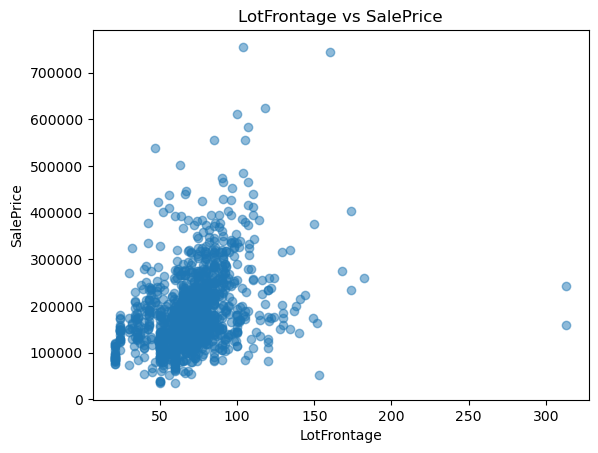

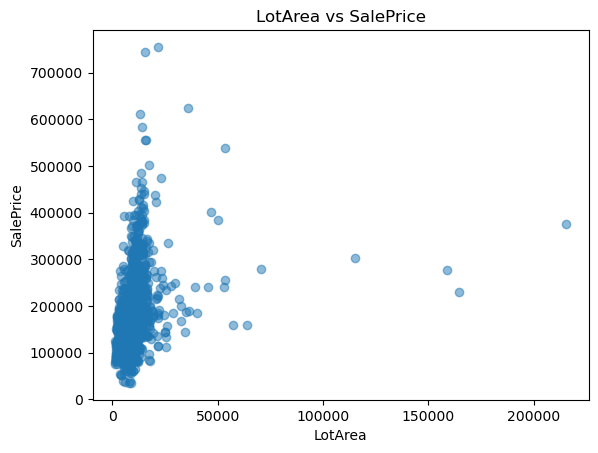

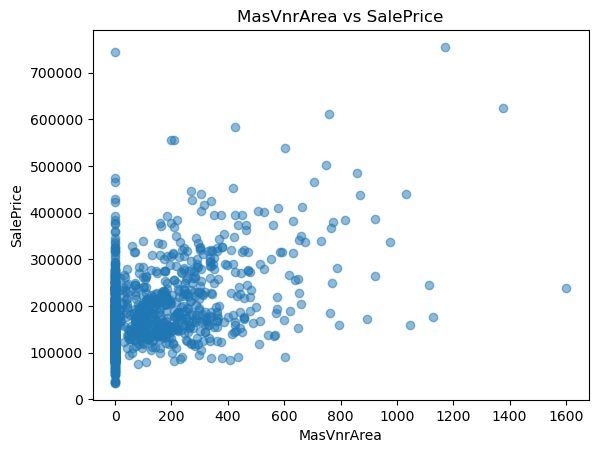

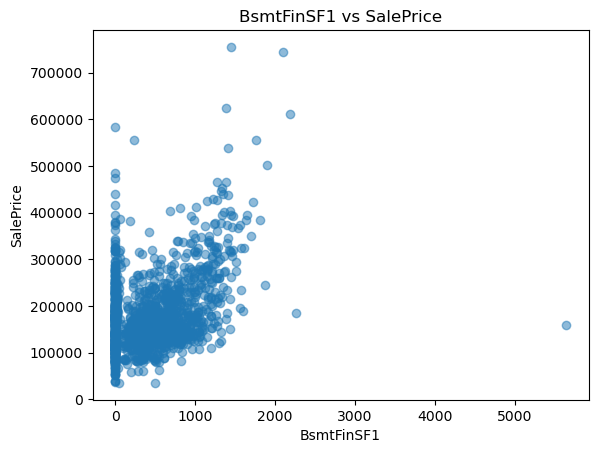

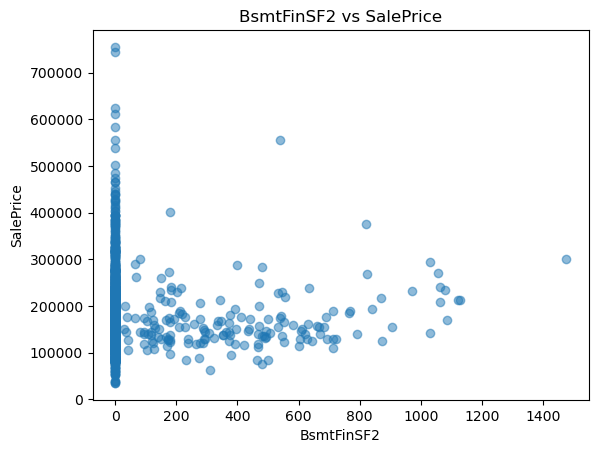

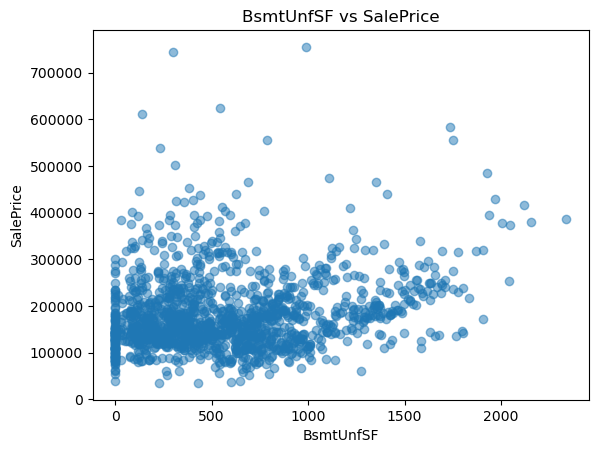

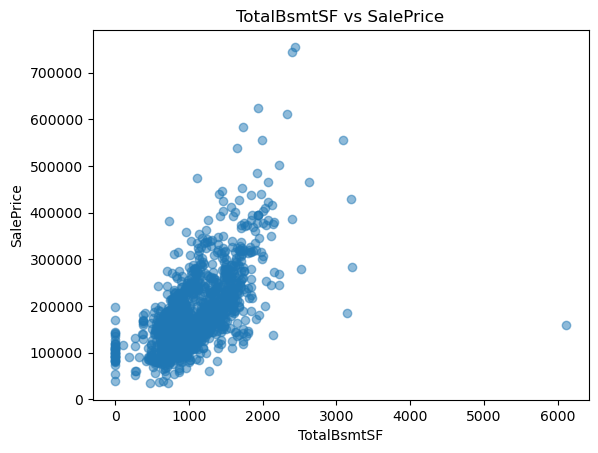

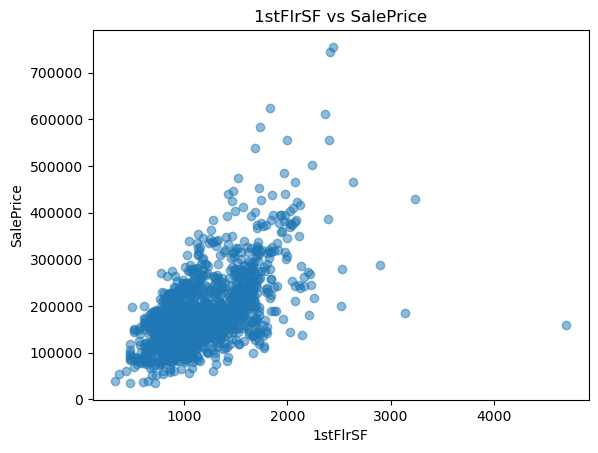

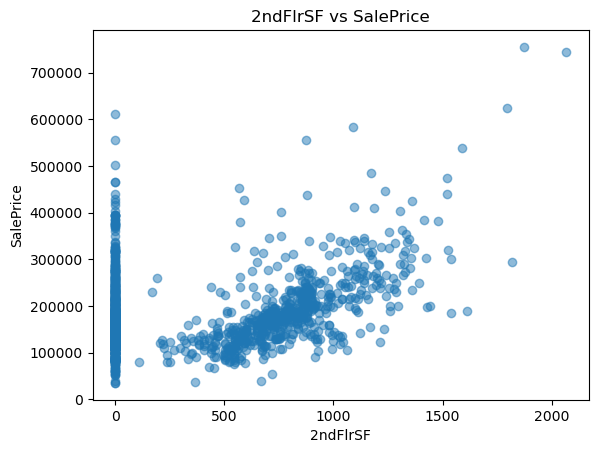

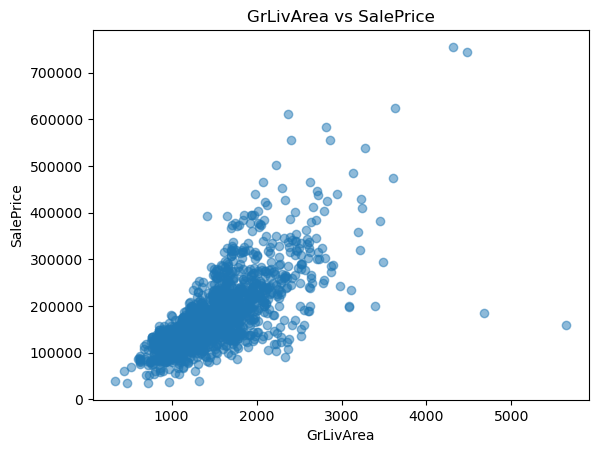

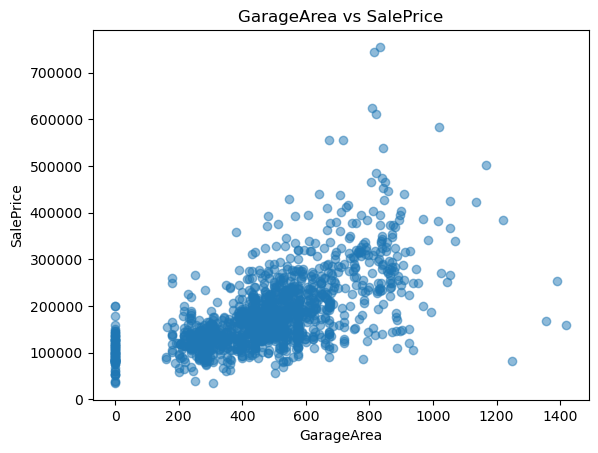

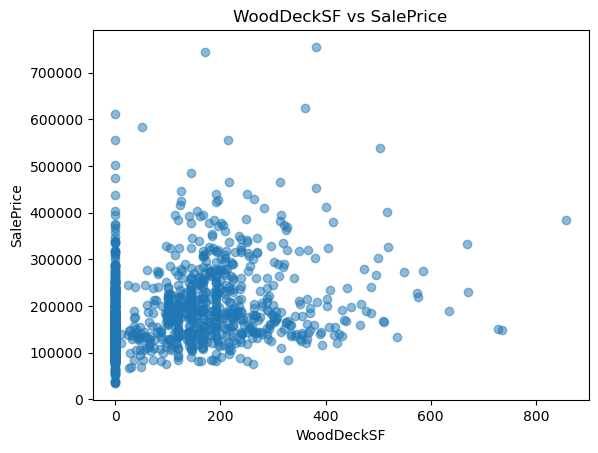

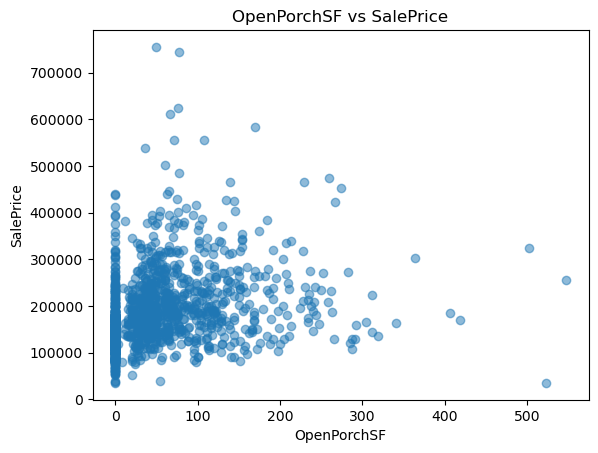

In [18]:
for col in outlier_cols:
    plt.scatter(df[col], df['SalePrice'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.title(f'{col} vs SalePrice')
    plt.show()

In [19]:
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000))]

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['TotalBsmtSF', 'GarageArea', 'LotArea', '1stFlrSF']:
    df = remove_outliers_iqr(df, col)

print(f'Rows remaining: {len(df)}')

Rows remaining: 1308


#### Scatter Plots AFTER Outlier Treatment

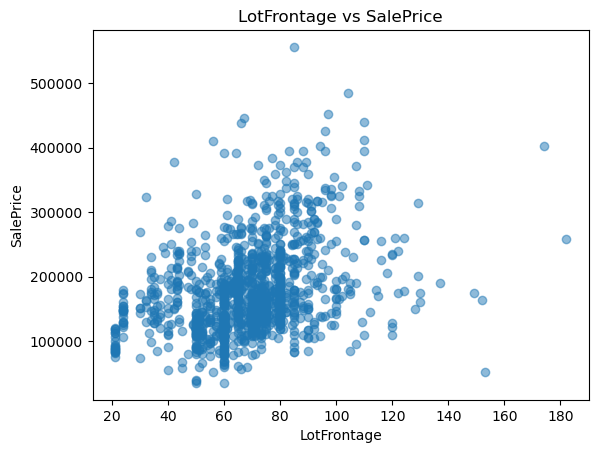

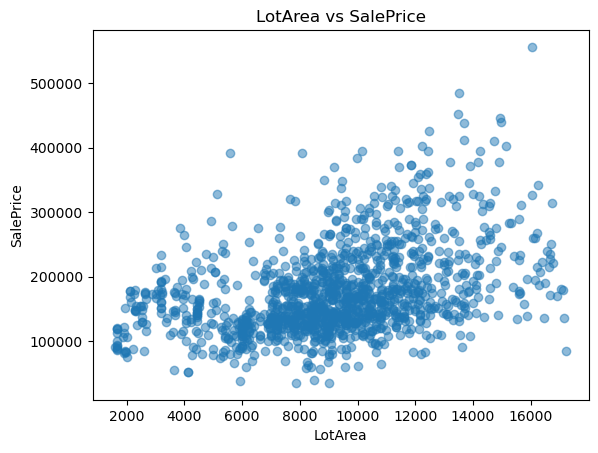

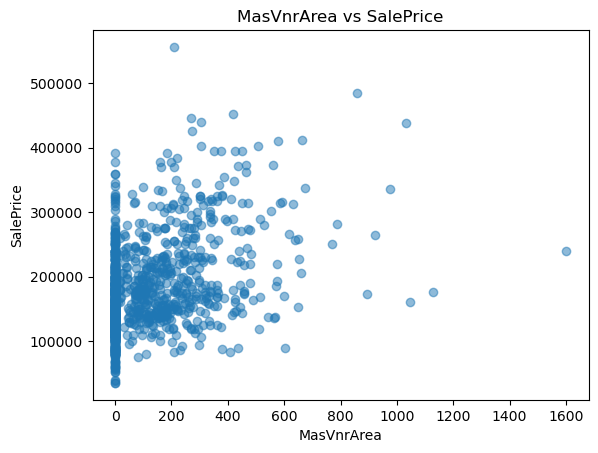

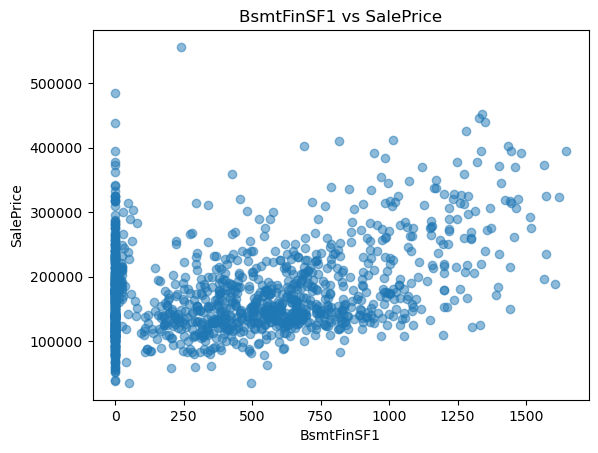

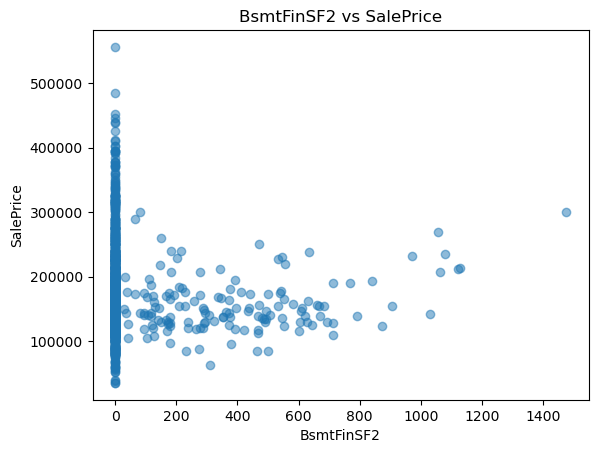

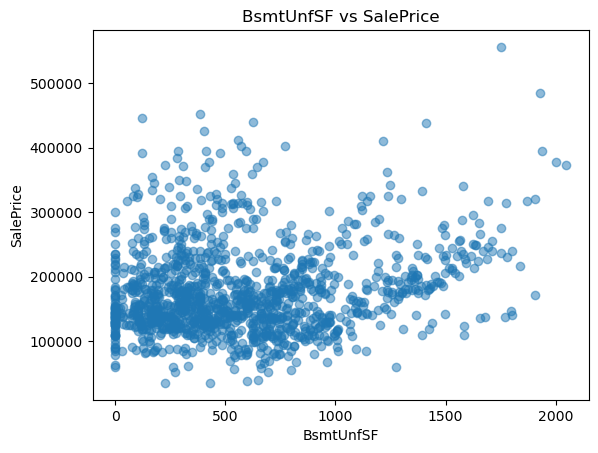

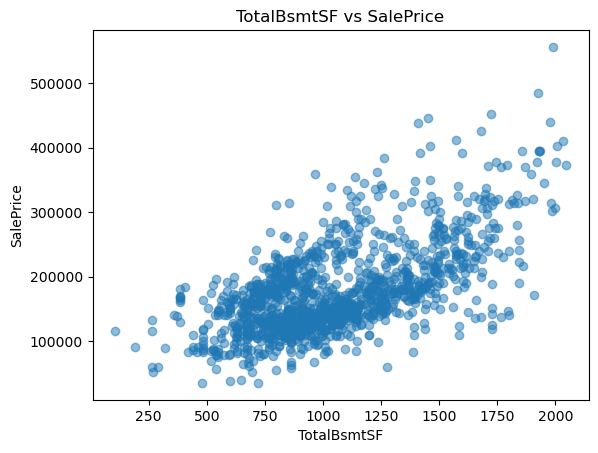

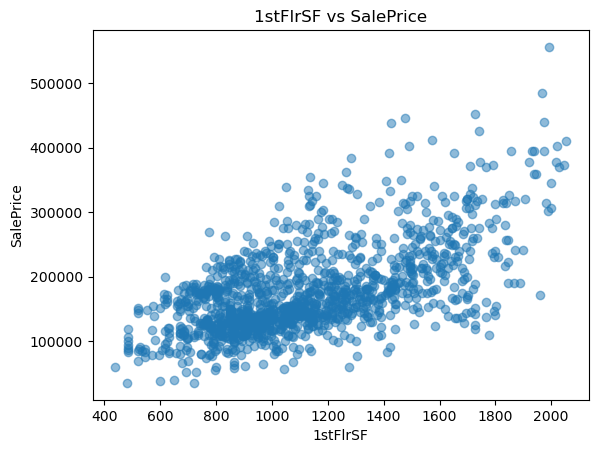

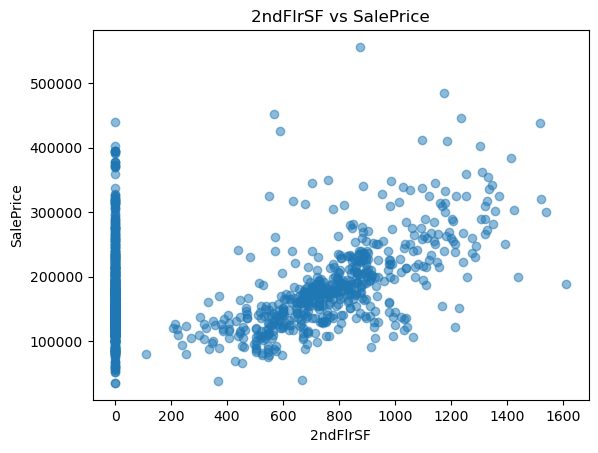

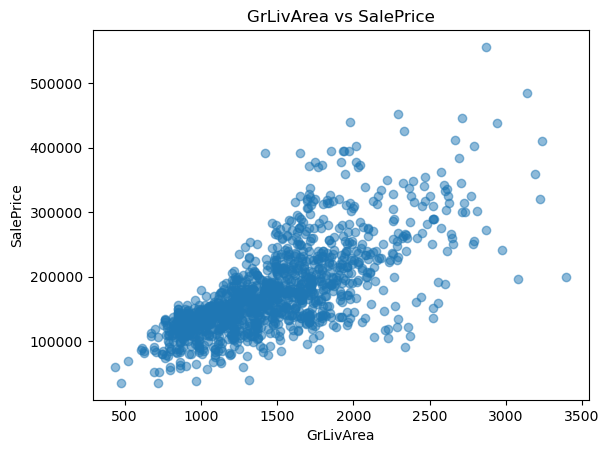

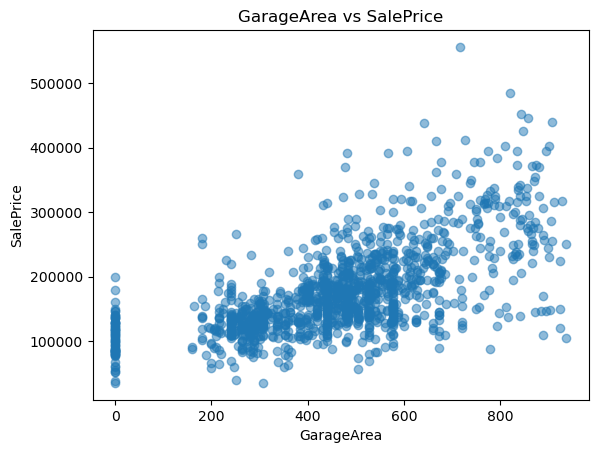

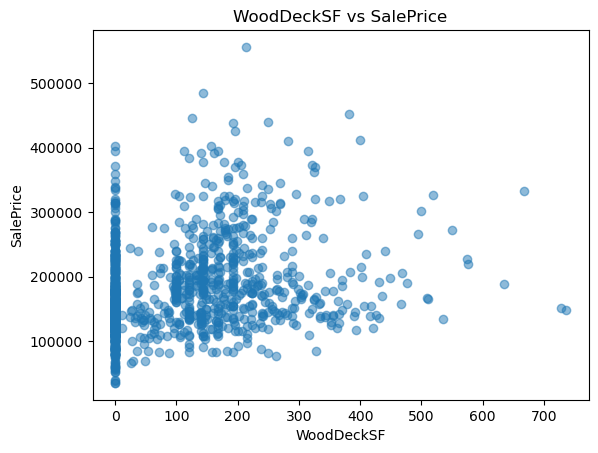

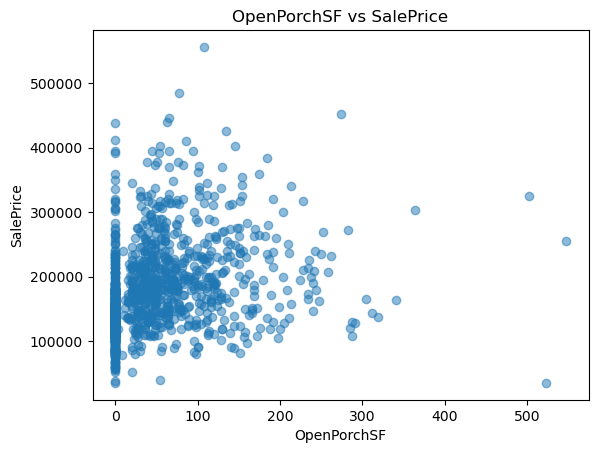

In [20]:
for col in outlier_cols:
    plt.scatter(df[col], df['SalePrice'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.title(f'{col} vs SalePrice')
    plt.show()

### Outlier Treatment
Outlier treatment is applied selectively based on **scatter plot analysis** and
**domain knowledge** of the Ames Housing dataset. Not all extreme values require
removal — high values in features such as `WoodDeckSF` or `OpenPorchSF` reflect
larger, higher-value properties and are considered valid observations.

Outliers were not removed solely based on statistical thresholds. Each candidate
observation was evaluated based on its **relationship with the target variable (`SalePrice`)**.

**Decision Criteria:**
- Observations were removed only if they were:
  - **Statistically extreme** (identified via scatter plots or IQR), and  
  - **Contextually inconsistent** with the expected relationship between the feature and `SalePrice`

- Observations were retained if they:
  - Represented **legitimate high-value properties**, even if extreme  
  - Followed a **reasonable trend with the target variable**

**Key Principle:**
- Extreme values are not inherently outliers  
- Only those that **violate both statistical and contextual expectations** are treated as anomalies

---

The following features were identified as containing **genuine anomalies**:

- **`GrLivArea`**:
  - Two well-documented observations with above-ground living area exceeding
    4000 sqft but unusually low sale prices  
  - Likely represent partial sales or data entry inconsistencies  
  - Removed using a **manual threshold filter**

- **`TotalBsmtSF`**:
  - One observation with an abnormally large basement (~6000 sqft)  
  - Falls significantly outside the general distribution  
  - Removed using the **IQR method**

- **`GarageArea`**:
  - One observation with a disproportionately large garage area relative to
    its sale price  
  - Removed using the **IQR method**

- **`LotArea`**:
  - A small number of extremely large lots (>100,000 sqft)  
  - Values are orders of magnitude higher than the typical range  
  - Removed using the **IQR method**

- **`1stFlrSF`**:
  - One extreme value aligned with the `GrLivArea` anomaly  
  - Removed using the **IQR method**

---

All remaining numerical features exhibit variability consistent with real-world
housing characteristics and are retained without modification.

**Rationale:**
- Only observations that are **statistically extreme and contextually inconsistent**
  are removed  
- Legitimate high-value properties are preserved to maintain dataset integrity

## 4. Fixing Skewed Features

After handling outliers, the next step is to examine the distribution of numerical features and identify variables that are noticeably skewed. Highly skewed features can affect statistical analysis and may reduce the effectiveness of machine learning models, especially those that are sensitive to feature distribution and scale.

To address this, the skewness of numerical columns will be measured and features with high positive skew will be transformed using suitable techniques such as logarithmic transformation. The goal is to reduce the influence of extreme values, make the distributions more balanced, and improve the overall quality of the feature set for downstream modeling.

Ordinal features are excluded from skewness correction, as their values represent ordered categories rather than continuous measurements. Applying transformations such as logarithmic scaling would distort their inherent ranking.

In [21]:
continuous_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ordinal_cols and col != 'Id' and col != 'SalePrice'
]
#get all the continuous-valued columns

In [22]:
skewness = df[continuous_cols].skew().sort_values(ascending=False)
skewness

MiscVal          29.610302
PoolArea         21.090775
3SsnPorch        11.158125
LowQualFinSF      9.282840
KitchenAbvGr      5.196245
BsmtFinSF2        4.439282
ScreenPorch       4.175778
BsmtHalfBath      4.108757
EnclosedPorch     2.852407
MasVnrArea        2.620388
OpenPorchSF       2.401072
WoodDeckSF        1.452231
MSSubClass        1.380335
BsmtUnfSF         0.893463
GrLivArea         0.754555
2ndFlrSF          0.713273
Fireplaces        0.679194
HalfBath          0.663055
TotRmsAbvGrd      0.657791
BsmtFinSF1        0.642163
BsmtFullBath      0.559879
1stFlrSF          0.549015
TotalBsmtSF       0.543033
LotFrontage       0.438042
BedroomAbvGr      0.297708
YrSold            0.102438
FullBath          0.016595
GarageArea       -0.124428
LotArea          -0.125096
GarageCars       -0.335119
YearRemodAdd     -0.540051
YearBuilt        -0.618244
GarageYrBlt      -0.726300
dtype: float64

In [23]:
skewed_cols = skewness[skewness.abs() > 0.5].index
skewed_candidates = list(skewed_cols)
skewed_candidates

['MiscVal',
 'PoolArea',
 '3SsnPorch',
 'LowQualFinSF',
 'KitchenAbvGr',
 'BsmtFinSF2',
 'ScreenPorch',
 'BsmtHalfBath',
 'EnclosedPorch',
 'MasVnrArea',
 'OpenPorchSF',
 'WoodDeckSF',
 'MSSubClass',
 'BsmtUnfSF',
 'GrLivArea',
 '2ndFlrSF',
 'Fireplaces',
 'HalfBath',
 'TotRmsAbvGrd',
 'BsmtFinSF1',
 'BsmtFullBath',
 '1stFlrSF',
 'TotalBsmtSF',
 'YearRemodAdd',
 'YearBuilt',
 'GarageYrBlt']

In [24]:
(df[continuous_cols] == 0).mean().sort_values(ascending = False) * 100

PoolArea         99.770642
3SsnPorch        98.547401
LowQualFinSF     98.318043
MiscVal          96.559633
BsmtHalfBath     94.342508
ScreenPorch      92.201835
BsmtFinSF2       88.914373
EnclosedPorch    85.474006
HalfBath         62.461774
MasVnrArea       59.097859
BsmtFullBath     59.021407
2ndFlrSF         56.498471
WoodDeckSF       51.987768
Fireplaces       49.311927
OpenPorchSF      45.259939
BsmtFinSF1       30.886850
BsmtUnfSF         5.733945
GarageCars        5.351682
GarageArea        5.351682
FullBath          0.535168
BedroomAbvGr      0.305810
KitchenAbvGr      0.076453
MSSubClass        0.000000
GarageYrBlt       0.000000
TotRmsAbvGrd      0.000000
LotFrontage       0.000000
GrLivArea         0.000000
1stFlrSF          0.000000
TotalBsmtSF       0.000000
YearRemodAdd      0.000000
YearBuilt         0.000000
LotArea           0.000000
YrSold            0.000000
dtype: float64

In [25]:
remove_cols = [
    # zero-heavy (already known junk for log)
    'MiscVal', 'PoolArea', '3SsnPorch', 'LowQualFinSF',
    'ScreenPorch', 'BsmtHalfBath',

    # count / discrete features (don’t log these)
    'KitchenAbvGr', 'Fireplaces', 'HalfBath', 'TotRmsAbvGrd', 'BsmtFullBath',

    # pseudo-categorical / codes
    'MSSubClass',

    # year-based (not continuous magnitude)
    'YearRemodAdd', 'YearBuilt', 'GarageYrBlt'
]

In [26]:
final_transform_cols = []

for col in continuous_cols:
    if (
        col not in remove_cols
        and col in skewed_cols
        and df[col].nunique() > 20
        and (df[col] == 0).mean() < 0.70
    ):
        final_transform_cols.append(col)

df[final_transform_cols].skew()

MasVnrArea     2.620388
BsmtFinSF1     0.642163
BsmtUnfSF      0.893463
TotalBsmtSF    0.543033
1stFlrSF       0.549015
2ndFlrSF       0.713273
GrLivArea      0.754555
WoodDeckSF     1.452231
OpenPorchSF    2.401072
dtype: float64

Numerical features were filtered to retain only continuous variables based on data type and cardinality. Skewness was then computed, and features with moderate to strong positive skew (skewness > 0.5) were selected as candidates for transformation.

Additional filtering criteria were applied to ensure suitability:
- Non-negative values (required for logarithmic transformation)
- Sufficient number of unique values (to exclude discrete variables)
- Low dominance of zero values (to avoid ineffective transformations)
- Exclusion of the target variable (`SalePrice`)

In [27]:
df[final_transform_cols].head()

,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,WoodDeckSF,OpenPorchSF
0,196,706,150,856,856,854,1710,0,61
1,0,978,284,1262,1262,0,1262,298,0
2,162,486,434,920,920,866,1786,0,42
3,0,216,540,756,961,756,1717,0,35
4,350,655,490,1145,1145,1053,2198,192,84


In [28]:
df_copy = df[final_transform_cols].copy()
for col in df_copy:
    df_copy[col] = np.log1p(df_copy[col])

for col in final_transform_cols:
    print(f'Original skewness for {col}: {df[col].skew()}\nAfter Log transform: {df_copy[col].skew()}\n\n')

Original skewness for MasVnrArea: 2.6203878721077865
After Log transform: 0.4788743396074445


Original skewness for BsmtFinSF1: 0.642163237963974
After Log transform: -0.6701972134927631


Original skewness for BsmtUnfSF: 0.8934627283979321
After Log transform: -2.506444534448572


Original skewness for TotalBsmtSF: 0.5430331153854964
After Log transform: -0.5875345589744184


Original skewness for 1stFlrSF: 0.549015484766102
After Log transform: -0.07316416757449622


Original skewness for 2ndFlrSF: 0.7132729888628007
After Log transform: 0.276459669435922


Original skewness for GrLivArea: 0.7545554797733348
After Log transform: -0.09831364608812751


Original skewness for WoodDeckSF: 1.4522313998869565
After Log transform: 0.14725198687054336


Original skewness for OpenPorchSF: 2.40107168245756
After Log transform: -0.01409826957646359




In [29]:
print(f'Original skewness for BsmtUnfSF: {df['BsmtUnfSF'].skew()}\n')

df_sqrt = df['BsmtUnfSF'].copy()
df_cbrt = df['BsmtUnfSF'].copy()

print(f'Skewness after square-root transformation: {np.sqrt(df_sqrt).skew()}')
print(f'Skewness after cube-root transformation: {np.cbrt(df_cbrt).skew()}')

Original skewness for BsmtUnfSF: 0.8934627283979321

Skewness after square-root transformation: -0.22538904329978507
Skewness after cube-root transformation: -1.0307164852614665


In [30]:
print(f'Original skewness for BsmtFinSF1: {df['BsmtFinSF1'].skew()}\n')

df_sqrt = df['BsmtFinSF1'].copy()
df_cbrt = df['BsmtFinSF1'].copy()

print(f'Skewness after square-root transformation: {np.sqrt(df_sqrt).skew()}')
print(f'Skewness after cube-root transformation: {np.cbrt(df_cbrt).skew()}')

Original skewness for BsmtFinSF1: 0.642163237963974

Skewness after square-root transformation: -0.1558738511220182
Skewness after cube-root transformation: -0.429042294917309


In [31]:
print(f'Original skewness for TotalBsmtSF: {df['TotalBsmtSF'].skew()}\n')

df_sqrt = df['TotalBsmtSF'].copy()
df_cbrt = df['TotalBsmtSF'].copy()

print(f'Skewness after square-root transformation: {np.sqrt(df_sqrt).skew()}')
print(f'Skewness after cube-root transformation: {np.cbrt(df_cbrt).skew()}')

Original skewness for TotalBsmtSF: 0.5430331153854964

Skewness after square-root transformation: 0.09582953544289582
Skewness after cube-root transformation: -0.09288454652911159


In [32]:
sqrt_transform_cols = ['BsmtUnfSF', 'BsmtFinSF1']
for col in final_transform_cols:
    if(col not in sqrt_transform_cols and col != 'TotalBsmtSF'):
        df[col] = np.log1p(df[col])
for col in sqrt_transform_cols:
    df[col] = np.sqrt(df[col])
    
df['TotalBsmtSF'] = np.cbrt(df['TotalBsmtSF'])

df[final_transform_cols].skew()

MasVnrArea     0.478874
BsmtFinSF1    -0.155874
BsmtUnfSF     -0.225389
TotalBsmtSF   -0.092885
1stFlrSF      -0.073164
2ndFlrSF       0.276460
GrLivArea     -0.098314
WoodDeckSF     0.147252
OpenPorchSF   -0.014098
dtype: float64

In [33]:
df[final_transform_cols].isnull().sum()

MasVnrArea     0
BsmtFinSF1     0
BsmtUnfSF      0
TotalBsmtSF    0
1stFlrSF       0
2ndFlrSF       0
GrLivArea      0
WoodDeckSF     0
OpenPorchSF    0
dtype: int64

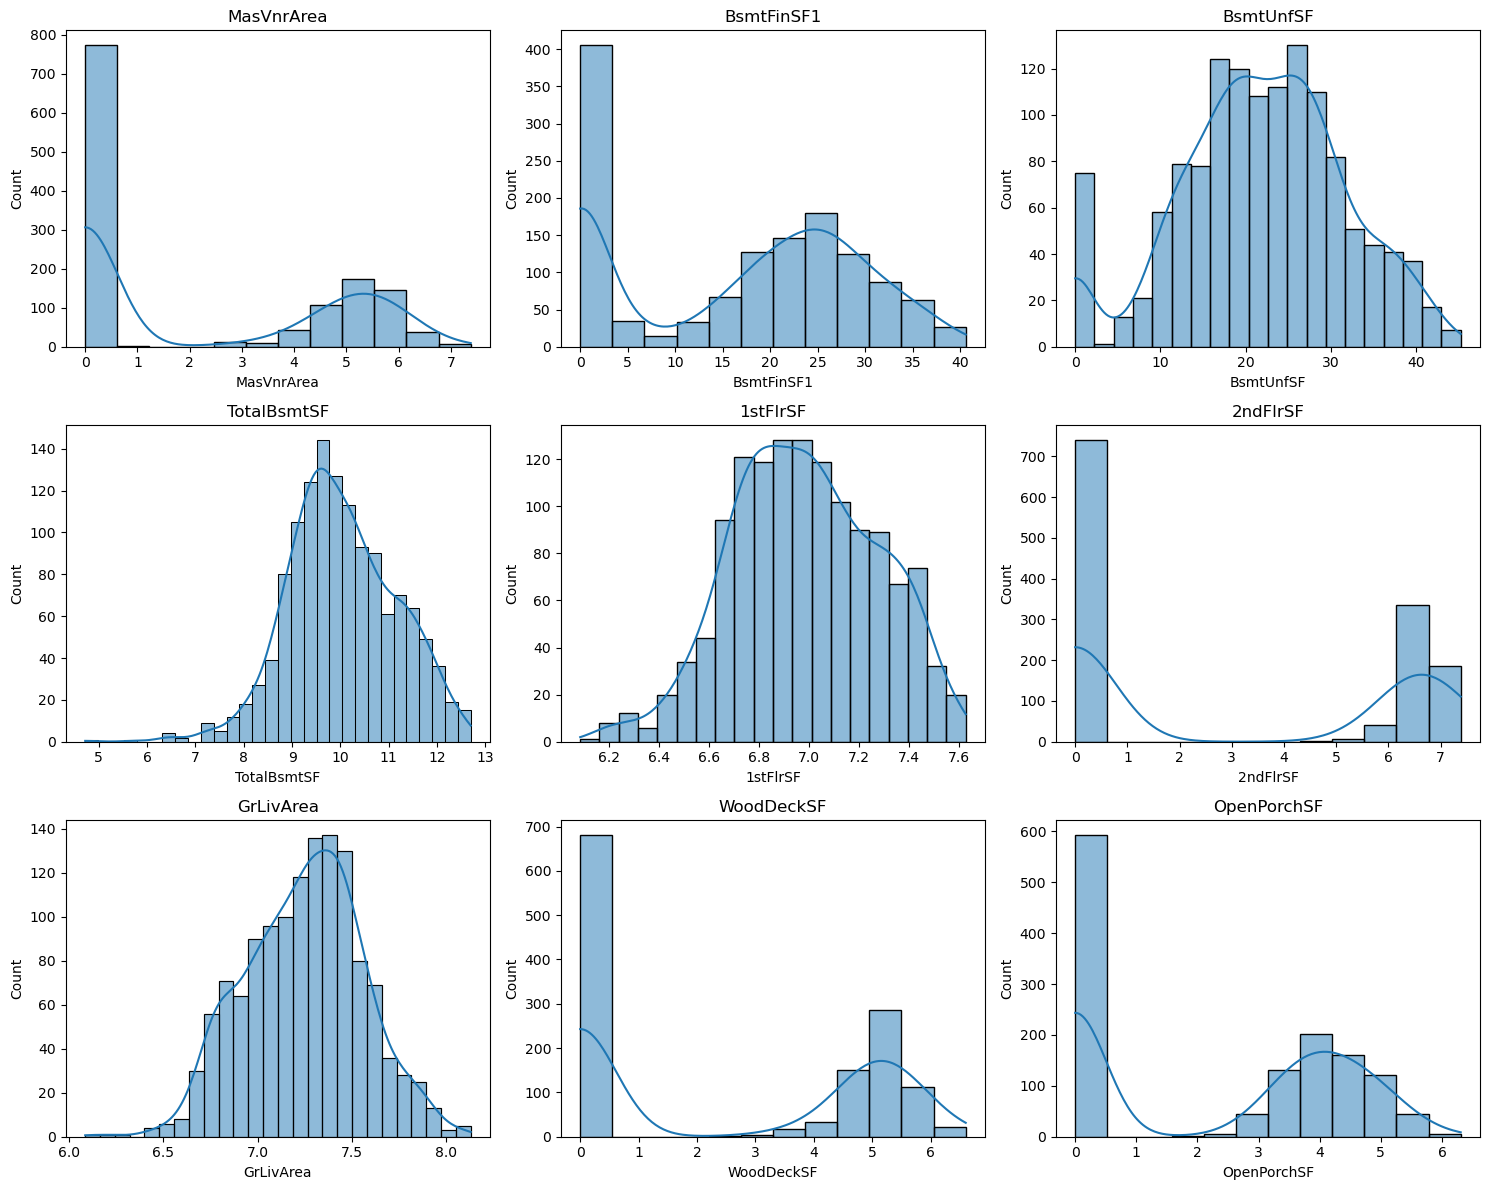

In [34]:
n_cols = 3
n_rows = (len(final_transform_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(final_transform_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

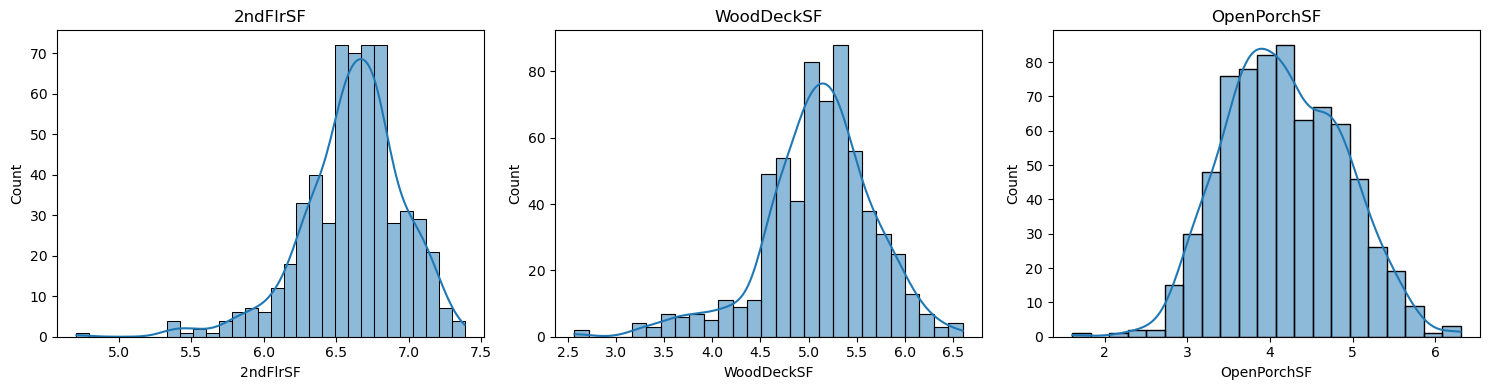

In [35]:
zero_heavy = ['2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF']
n_cols = 3
n_rows = 1

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(zero_heavy, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[df[col] > 0][col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

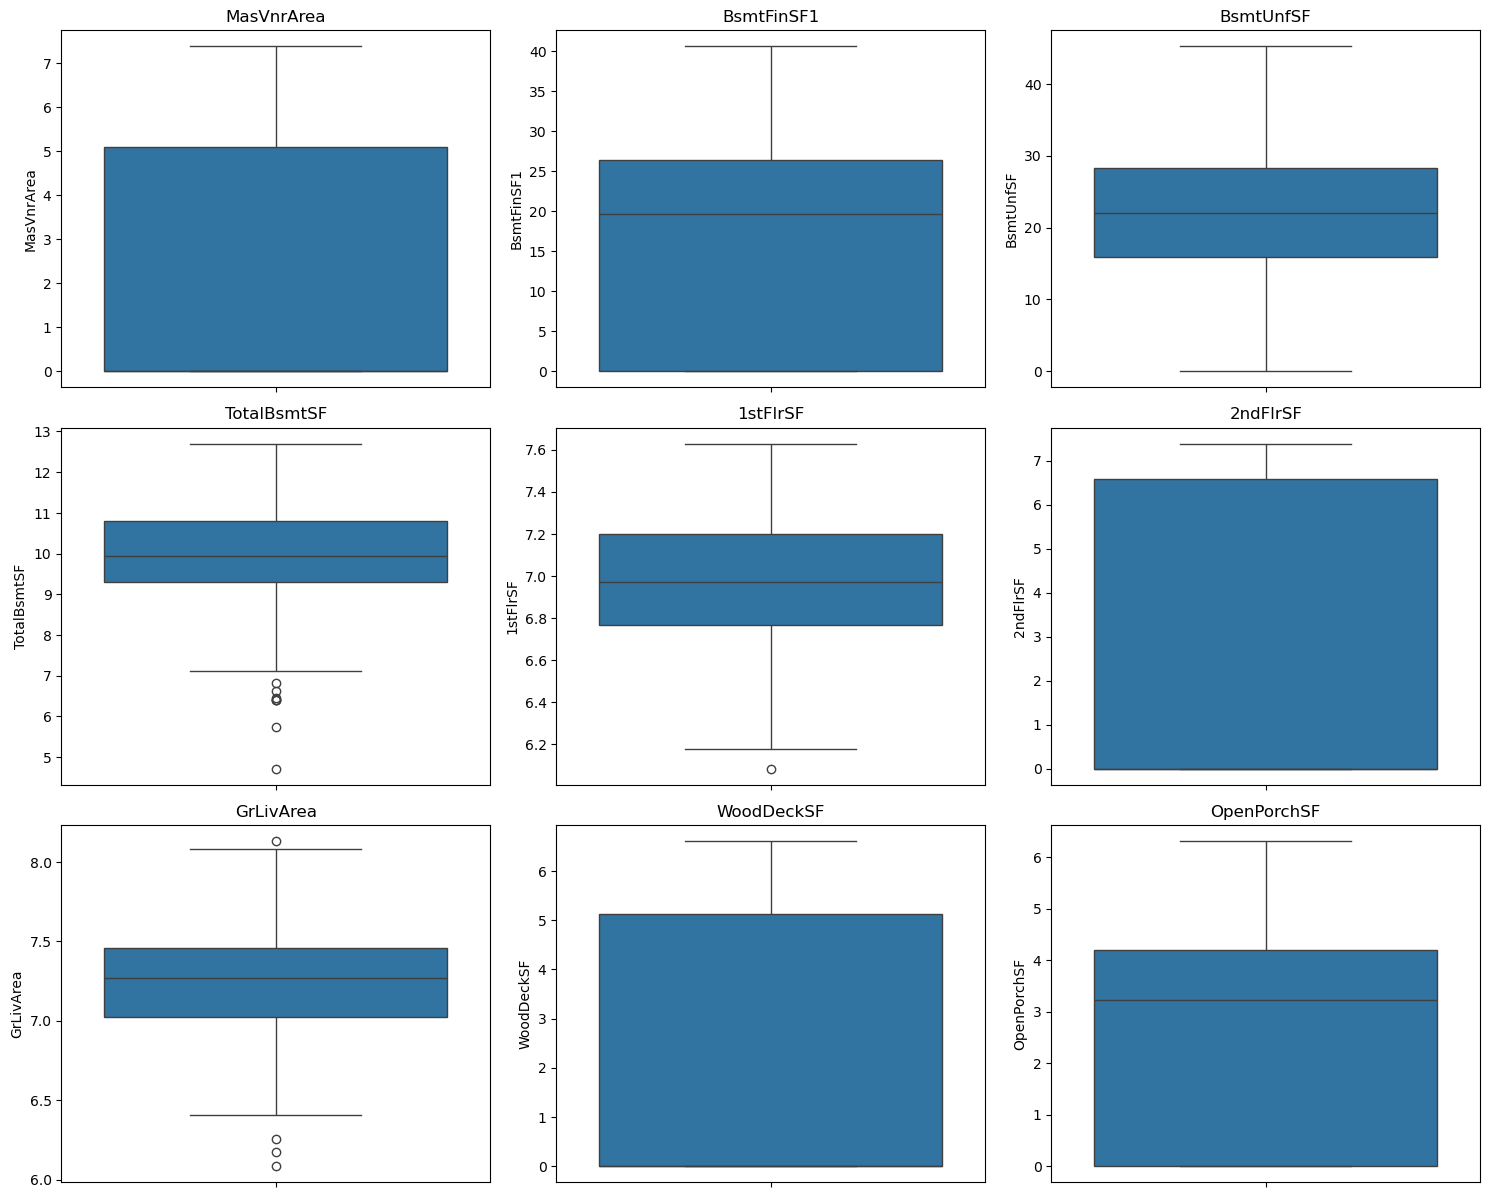

In [36]:
cols = final_transform_cols
rows = len(cols) // 3 + 1
plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [37]:
corr = df[final_transform_cols + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
corr

SalePrice      1.000000
GrLivArea      0.691687
TotalBsmtSF    0.595216
1stFlrSF       0.580313
OpenPorchSF    0.439414
MasVnrArea     0.419975
WoodDeckSF     0.330122
BsmtFinSF1     0.237904
2ndFlrSF       0.165383
BsmtUnfSF      0.165200
Name: SalePrice, dtype: float64

## 5. Feature Engineering

With data types corrected, missing values handled, outliers treated, and skewed features transformed, the dataset is now in a suitable state for feature engineering.

Feature engineering focuses on creating new variables and refining existing ones to better capture the underlying patterns in the data. This step aims to improve model performance by enhancing the representation of important relationships.

**Objectives:**
- Derive meaningful features from existing variables  
- Capture hidden patterns and interactions  
- Simplify or restructure features where necessary  
- Improve predictive power of the dataset  

**Approach:**
- Create new features based on domain knowledge (e.g., total area, age of property)  
- Combine related features to form more informative variables  
- Convert relevant numerical features into categorical representations where appropriate  
- Generate binary indicators for the presence or absence of certain property attributes  

This step transforms the dataset from a cleaned version into a more informative and model-ready form.

In [38]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['TotalPorchSF'] = (
    df['OpenPorchSF'] +
    df['EnclosedPorch'] +
    df['3SsnPorch'] +
    df['ScreenPorch']
)

df['TotalBath'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

### Feature Engineering: Aggregation of Related Features

Certain features in the dataset represent fragmented components of a larger concept. Treating them independently can dilute their predictive power. Therefore, related features are combined to better represent real-world characteristics of a property.

**Key Transformations:**

- **Total Living Area (`TotalSF`)**
  - Combines basement, first floor, and second floor areas
  - Provides a more holistic measure of property size

- **Total Porch Area (`TotalPorchSF`)**
  - Aggregates all types of porch-related areas
  - Captures overall outdoor usable space

- **Total Bathrooms (`TotalBath`)**
  - Combines full and half bathrooms with appropriate weighting
  - Reflects overall bathroom availability more accurately than individual counts

**Rationale:**
- Aggregation reduces feature fragmentation and redundancy  
- Combined features better align with how properties are evaluated in reality  
- Improves signal strength and model interpretability  

This step enhances the dataset by transforming multiple weakly related variables into more meaningful and informative features.

In [39]:
# Binary presence features
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

df['HasWoodDeck'] = (df['WoodDeckSF'] > 0).astype(int)
df['HasOpenPorch'] = (df['OpenPorchSF'] > 0).astype(int)
df['HasEnclosedPorch'] = (df['EnclosedPorch'] > 0).astype(int)

df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)

### Feature Engineering: Binary Presence Features

Certain features in the dataset exhibit a high proportion of zero values, indicating the absence of a particular property attribute rather than a true continuous distribution.

For such features, the presence or absence of the attribute is often more informative than its magnitude. To capture this, binary indicators are created.

**Key Transformations:**

- `HasPool` → Indicates whether the property has a pool  
- `HasGarage` → Indicates presence of a garage  
- `HasFireplace` → Indicates presence of a fireplace  
- `HasBasement` → Indicates presence of a basement  
- `HasWoodDeck`, `HasOpenPorch`, `HasEnclosedPorch` → Capture outdoor space availability  
- `Has2ndFloor` → Indicates presence of a second floor  

**Rationale:**
- Zero-heavy features represent **absence vs presence**, not continuous variation  
- Binary encoding separates structural information from magnitude  
- Improves interpretability and helps models capture meaningful patterns  
- Aligns with real-world evaluation of properties (e.g., having a pool matters more than its exact size)

This step enhances the dataset by explicitly representing structural property characteristics that are otherwise embedded within numerical features.

In [40]:
df['LivArea_Qual'] = df['GrLivArea'] * df['OverallQual']
df['TotalSF_Qual'] = df['TotalSF'] * df['OverallQual']
df['Garage_Qual'] = df['GarageArea'] * df['OverallQual']
df['Bsmt_Qual'] = df['TotalBsmtSF'] * df['OverallQual']
df['Bath_Qual'] = df['TotalBath'] * df['OverallQual']

### Feature Engineering: Interaction Features

Certain relationships in the dataset are not captured effectively by individual features alone. Instead, the combined effect of multiple features provides stronger predictive power.

To capture these interactions, new features are created by combining relevant variables.

**Key Transformations:**

- `LivArea_Qual` → Combines living area with overall quality  
- `TotalSF_Qual` → Captures interaction between total area and property quality  
- `Garage_Qual` → Combines garage size and overall quality 
- `Bsmt_Qual` → Reflects basement size adjusted by overall quality  
- `Bath_Qual` → Combines number of bathrooms with overall quality  

**Rationale:**
- Property value is influenced by **multiple interacting factors**, not isolated variables  
- Interaction features help capture **non-linear relationships**  
- Enhances model performance by introducing meaningful feature combinations  
- Reflects real-world valuation patterns (e.g., large high-quality homes are significantly more valuable than large low-quality ones)

This step enriches the dataset by incorporating relationships between features that are otherwise not explicitly represented.

### Refinement of Interaction Features

During the feature engineering process, an initial interaction feature combining `GarageArea` and `GarageCars` was considered. However, further analysis indicated that this interaction does not provide additional meaningful information.

**Observation:**
- `GarageArea` and `GarageCars` are inherently correlated  
- Larger garages typically accommodate more cars  
- Their product amplifies an already existing relationship rather than introducing a new one  

**Decision:**
- The interaction feature `GarageArea × GarageCars` is removed  
- Replaced with a more meaningful interaction: `GarageArea × OverallQual`  

**Rationale:**
- Avoids redundancy and multicollinearity  
- Ensures interaction features capture relationships between **distinct dimensions** (size × quality)  
- Maintains consistency with other interaction features in the dataset  

This refinement ensures that engineered features contribute new and relevant information rather than duplicating existing signals.

In [41]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
df['IsNew'] = (df['YearBuilt'] == df['YrSold']).astype(int)

### Feature Engineering: Temporal (Age-Based) Features

Year-based features in their raw form do not provide meaningful insight into property value. Instead, the relative age of a property and its components is more informative.

To capture this, new features are derived based on differences between the year of sale and relevant year attributes.

**Key Transformations:**

- `HouseAge` → Age of the property at the time of sale  
- `RemodAge` → Years since last remodeling  
- `GarageAge` → Age of the garage  
- `IsRemodeled` → Indicates whether the property has been remodeled  
- `IsNew` → Indicates if the house was newly built at the time of sale  

**Rationale:**
- Property value is influenced by **age and modernization**, not absolute year values  
- Relative features better capture depreciation and renovation effects  
- Binary indicators simplify important structural distinctions (e.g., new vs old, remodeled vs not)

This step improves the dataset by converting raw temporal information into features that better reflect real-world valuation dynamics.

In [42]:
print((df['HouseAge'] < 0).sum())
print((df['GarageAge'] < 0).sum())
print((df['RemodAge'] < 0).sum())

0
0
0


In [43]:
engineered_features = [
    # Aggregation
    'TotalSF', 'TotalPorchSF', 'TotalBath',

    # Binary
    'HasPool', 'HasGarage', 'HasFireplace', 'HasBasement',
    'HasWoodDeck', 'HasOpenPorch', 'HasEnclosedPorch', 'Has2ndFloor',

    # Interactions
    'LivArea_Qual', 'TotalSF_Qual', 'Garage_Qual',
    'Bsmt_Qual', 'Bath_Qual',

    # Temporal
    'HouseAge', 'RemodAge', 'GarageAge',
    'IsRemodeled', 'IsNew'
]

In [44]:
df[engineered_features].isnull().sum()

TotalSF             0
TotalPorchSF        0
TotalBath           0
HasPool             0
HasGarage           0
HasFireplace        0
HasBasement         0
HasWoodDeck         0
HasOpenPorch        0
HasEnclosedPorch    0
Has2ndFloor         0
LivArea_Qual        0
TotalSF_Qual        0
Garage_Qual         0
Bsmt_Qual           0
Bath_Qual           0
HouseAge            0
RemodAge            0
GarageAge           0
IsRemodeled         0
IsNew               0
dtype: int64

In [45]:
df[engineered_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

SalePrice           1.000000
Bsmt_Qual           0.853935
LivArea_Qual        0.843482
Bath_Qual           0.814394
Garage_Qual         0.809705
TotalSF_Qual        0.795442
TotalBath           0.632753
HasFireplace        0.466913
TotalSF             0.460187
HasOpenPorch        0.424685
HasWoodDeck         0.308757
IsNew               0.273471
HasGarage           0.247588
Has2ndFloor         0.135979
HasPool             0.017821
TotalPorchSF       -0.043219
IsRemodeled        -0.071269
HasEnclosedPorch   -0.222470
RemodAge           -0.547864
GarageAge          -0.554363
HouseAge           -0.584108
HasBasement              NaN
Name: SalePrice, dtype: float64

In [46]:
df['HasBasement'].value_counts()

HasBasement
1    1308
Name: count, dtype: int64

### Feature Evaluation: Correlation Analysis and Multicollinearity

After completing feature engineering, the relationship between engineered features and the target variable (`SalePrice`) was evaluated using correlation analysis.

**Key Observations:**

- Interaction features such as `TotalSF_Qual`, `Bsmt_Qual`, `LivArea_Qual`, and `Bath_Qual` exhibit the strongest positive correlation with the target variable  
- Aggregated features like `TotalSF` and `TotalBath` also show strong predictive relationships  
- Binary features (e.g., `HasFireplace`, `HasOpenPorch`) demonstrate moderate correlation, which is expected as they capture structural presence rather than magnitude  
- Temporal features (`HouseAge`, `GarageAge`, `RemodAge`) show strong negative correlation, indicating that older properties tend to have lower sale prices  

**Feature Refinement:**

- Features with negligible or no correlation (e.g., `HasPool`, `TotalPorchSF`) are identified as low-impact and may be removed in later stages  
- `HasBasement` resulted in undefined correlation due to lack of variance and is removed from the dataset  

**Multicollinearity Considerations:**

Several high-performing features are derived from related base variables (e.g., area-based and interaction features). As a result, multicollinearity is expected among:

- `TotalSF`, `GrLivArea`, `TotalSF_Qual`, `LivArea_Qual`, `Bsmt_Qual`

This is a natural outcome of feature engineering and does not necessarily indicate an issue.

**Decision:**

- Multicollinearity is tolerated at this stage, as the primary objective is predictive performance  
- Tree-based models (e.g., Random Forest, Gradient Boosting) are robust to correlated features and can effectively utilize multiple representations of the same signal  
- Feature reduction or regularization may be considered later if linear models are used  

**Conclusion:**

The engineered feature set demonstrates strong alignment with the target variable, with high-impact features capturing both magnitude and interaction effects. Redundant or low-signal features are minimal, and the dataset is now well-prepared for model training and evaluation.

In [47]:
df.drop(columns=['HasBasement', 'HasPool', 'TotalPorchSF', 'IsRemodeled'], inplace=True)

## Feature Selection — Refinement of Engineered Features

Following feature engineering, correlations with the target variable (`SalePrice`) were evaluated to identify low-signal or redundant features.

The following features were removed based on statistical and structural considerations:

| Feature | Correlation | Reason for Dropping |
|---|---|---|
| `HasBasement` | NaN | Zero variance — all observations have a basement after preprocessing. Provides no discriminative information. |
| `HasPool` | 0.017 | Extremely low correlation. Pool presence is rare in the dataset and contributes negligible predictive signal. |
| `TotalPorchSF` | -0.043 | Weak correlation. Porch-related information is already captured through individual features (`OpenPorchSF`, `WoodDeckSF`) and corresponding binary indicators, making this aggregation redundant. |
| `IsRemodeled` | -0.071 | Weak binary signal. Remodeling effects are more effectively captured by `RemodAge`, which encodes recency rather than a simple presence indicator. |

---

### Note on Negative Correlations

Features such as `HouseAge`, `RemodAge`, and `GarageAge` are retained despite negative correlations. These represent meaningful inverse relationships — older properties tend to have lower sale prices — and therefore provide strong predictive value.

---

### Retained Feature Justification

**`HasEnclosedPorch` is retained** despite its negative correlation (-0.22), as the direction of the relationship is meaningful rather than arbitrary. Enclosed porches are more common in older construction styles and tend to be associated with lower-value properties. This negative correlation reflects a genuine architectural pattern and provides useful signal for distinguishing older, lower-value homes from more modern, higher-value ones.

---

### Key Considerations

- Features were removed only when they were **uninformative (zero variance / negligible correlation)** or **redundant with stronger representations**
- Correlation was used as a guiding metric, supplemented by domain understanding and feature relationships

---

### Conclusion

These refinements result in a more concise and informative feature set while preserving meaningful predictive signals for downstream modeling.

## 6. Encoding Categorical Features

With numerical preprocessing complete, the final step is to convert categorical features into a format suitable for machine learning models. Since most models cannot directly handle string-based inputs, encoding is required before training.

### Identifying Categorical Features

The dataset contains two types of categorical features, each requiring a different approach:

- **Ordinal features** — categories with a meaningful order  
  (e.g., `ExterQual`: Po < Fa < TA < Gd < Ex)
- **Nominal features** — categories without any inherent order  
  (e.g., `Neighborhood`, `GarageType`, `SaleCondition`)

Choosing the correct encoding strategy is important:
- One-hot encoding ordinal features removes useful ranking information  
- Label encoding nominal features introduces artificial ordering  

### Strategy 1: Ordinal Encoding

Ordinal features are encoded using manually defined mappings that preserve their natural ranking. This allows the model to interpret differences between categories meaningfully instead of treating them as unrelated values.

This approach is applied to:
- Quality and condition features (`ExterQual`, `BsmtQual`, `KitchenQual`, `FireplaceQu`, `GarageQual`, etc.)
- Basement and garage-related ratings (`BsmtExposure`, `BsmtFinType1`, `GarageFinish`)
- Structural ordinal features (`LotShape`, `LandSlope`, `Utilities`, `Functional`, `PavedDrive`)

Missing categories, previously imputed as `"None"`, are mapped to `0`, representing the absence of the feature. This keeps the encoding consistent with earlier preprocessing steps.

### Strategy 2: One-Hot Encoding

Nominal features are encoded using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity caused by redundant dummy variables.

This approach is applied to:
- Location-based features (`Neighborhood`, `MSZoning`)
- Structural descriptors (`BldgType`, `HouseStyle`, `Foundation`)
- Material features (`Exterior1st`, `Exterior2nd`, `RoofMatl`)
- Sale and time-related features (`SaleType`, `SaleCondition`, `MoSold`)

Each category is converted into a binary indicator, allowing the model to treat them as distinct groups without assuming any order.

### Verification

After encoding, the dataset is validated to ensure:
- No object-type columns remain  
- No null values were introduced during mapping  
- The final dataset structure is consistent and ready for modeling

In [48]:
ordinal_mappings = {
    'ExterQual':    {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'ExterCond':    {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtQual':     {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtCond':     {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtExposure': {'None':0,'No':1,'Mn':2,'Av':3,'Gd':4},
    'BsmtFinType1': {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'BsmtFinType2': {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'HeatingQC':    {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'KitchenQual':  {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'FireplaceQu':  {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'GarageFinish': {'None':0,'Unf':1,'RFn':2,'Fin':3},
    'GarageQual':   {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'GarageCond':   {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'PoolQC':       {'None':0,'Fa':1,'TA':2,'Gd':3,'Ex':4},
    'Fence':        {'None':0,'MnWw':1,'GdWo':2,'MnPrv':3,'GdPrv':4},
    'Functional':   {'Sal':1,'Sev':2,'Maj2':3,'Maj1':4,'Mod':5,'Min2':6,'Min1':7,'Typ':8},
    'LotShape':     {'IR3':1,'IR2':2,'IR1':3,'Reg':4},
    'LandSlope':    {'Sev':1,'Mod':2,'Gtl':3},
    'Utilities':    {'ELO':1,'NoSeWa':2,'NoSewr':3,'AllPub':4},
    'PavedDrive':   {'N':0,'P':1,'Y':2},
    'CentralAir':   {'N':0,'Y':1},
}

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

In [49]:
nominal_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig',
                'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
                'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating',
                'Electrical', 'GarageType', 'MiscFeature', 'MoSold',
                'SaleType', 'SaleCondition']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [50]:
print(df.shape)
print(df.select_dtypes(include='object').columns.tolist())  # should be empty
print(df.isnull().sum().sum())  # should be 0

(1308, 221)
[]
0


## 7. Save Cleaned Dataset

At this stage, the preprocessing pipeline is complete and the dataset has been 
transformed into a clean, structured format ready for modeling.

### Summary of Steps Performed

| Step | Action |
|---|---|
| **1. Fix Data Types** | Converted relevant float features (`GarageYrBlt`, `LotFrontage`, `MasVnrArea`) to integer form after handling missing values; treated `MoSold` as a categorical feature |
| **2. Handle Missing Values** | Imputed feature-absence columns with `"None"`; used neighborhood-based median for `LotFrontage`, `YearBuilt` for `GarageYrBlt`, and mode for `Electrical` |
| **3. Handle Outliers** | Removed two known `GrLivArea` anomalies manually; applied selective IQR-based removal for `TotalBsmtSF`, `GarageArea`, `LotArea`, and `1stFlrSF` |
| **4. Fix Skewed Features** | Applied `log1p` transformation to highly skewed features and `sqrt` transformation to moderately skewed basement-related features (`BsmtUnfSF`, `BsmtFinSF1`, `TotalBsmtSF`) |
| **5. Feature Engineering** | Created new features including area aggregates, total bathrooms, interaction terms, binary indicators, and age-based variables |
| **6. Encoding** | Applied ordinal mapping with defined rankings and one-hot encoding for nominal features using `drop_first=True` |

### Final Dataset

- **Rows:** 1308 (after outlier removal from original 1460)  
- **Missing values:** 0  
- **Feature types:** All numerical (fully encoded and model-ready)  

The processed dataset is saved to `../data/processed_train.csv` and will be used 
directly in the modeling stage.

In [51]:
# drop Id
df = df.drop(columns=['Id'])

# convert booleans to int
bool_cols = df.select_dtypes(bool).columns
df[bool_cols] = df[bool_cols].astype(int)

# save
df.to_csv('../data/processed_train.csv', index=False)
print(df.shape)

(1308, 220)


In [52]:
df.to_csv('../data/processed_train.csv', index=False)
print(f'Saved: {df.shape}')

Saved: (1308, 220)
